# Colorization model with U-Net

## Imports

In [20]:
#Algebra
import numpy as np

#Graphics
import matplotlib.pyplot as plt
%matplotlib inline
from PIL import Image

#Deep learning
import tensorflow as tf
import tensorflow_io as tfio

from keras.models import Model
from keras import optimizers, callbacks
from keras.layers import Input, Flatten, Reshape, BatchNormalization, Concatenate
from keras.layers import Conv2D, MaxPooling2D, Conv2DTranspose
from keras.utils import image_dataset_from_directory

#Saving models
import joblib

## Training dataset

In [2]:
train_data_dir = '/kaggle/input/datasets/aayush9753/image-colorization-dataset/data/train_color'

## Parameters

In [3]:
BATCH_SIZE = 32

IMAGE_HEIGHT = 256
IMAGE_WIDTH = 256
IMAGE_SIZE = (IMAGE_HEIGHT, IMAGE_WIDTH)
NUM_CHANNELS = 3

SEED = 42

LEARNING_RATE = 0.01
PATIENCE = 10
EPOCHS = 100

In [4]:
train_ds, val_ds = image_dataset_from_directory(
    train_data_dir,
    labels=None,
    seed=SEED,
    validation_split=0.2,
    subset='both',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE)

Found 5000 files.
Using 4000 files for training.
Using 1000 files for validation.


I0000 00:00:1779109939.733793      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779109939.739830      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## Converting RGB to Lab

In [5]:
def rgb_to_lab(image):
    image = tf.cast(image, tf.float32) / 255.0
    lab = tfio.experimental.color.rgb_to_lab(image)
    L = lab[:, :, :, :1] / 100.
    ab = lab[:, :, :, 1:] / 128.
    return (L, ab)

In [6]:
train_ds_lab = train_ds.map(rgb_to_lab, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_lab = train_ds_lab.prefetch(tf.data.AUTOTUNE)
val_ds_lab = val_ds.map(rgb_to_lab, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_lab = val_ds_lab.prefetch(tf.data.AUTOTUNE)

## Defining the model

In [38]:
def initialize_model():

    ######################
    ###  Architecture  ###
    ######################

    inputs = Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 1))  #B&W images (L channel)

    #Encoder part
    e1 = Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same')(inputs)
    e1 = BatchNormalization()(e1)
    p1 = MaxPooling2D(pool_size=(2,2), padding='same')(e1)

    e2 = Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same')(p1)
    e2 = BatchNormalization()(e2)
    p2 = MaxPooling2D(pool_size=(2,2), padding='same')(e2)

    e3 = Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same')(p2)
    e3 = BatchNormalization()(e3)
    p3 = MaxPooling2D(pool_size=(2,2), padding='same')(e3)

    #Bottleneck
    e4 = Conv2D(filters=256, kernel_size=(3,3), activation='relu', padding='same')(p3)
    e4 = BatchNormalization()(e4)
    # x = MaxPooling2D(pool_size=(2,2), padding='same')(x)

    #Decoder part
    
    u3 = Conv2DTranspose(128, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='same')(e4)
    u3 = Concatenate()([u3, e3])
    u3 = BatchNormalization()(u3)
    
    u2 = Conv2DTranspose(64, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='same')(u3)
    u2 = Concatenate()([u2, e2])
    u2 = BatchNormalization()(u2)
    
    u1 = Conv2DTranspose(32, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='same')(u2)
    u1 = Concatenate()([u1, e1])
    u1 = BatchNormalization()(u1)
    
    outputs = Conv2DTranspose(2, kernel_size=(3, 3), activation='tanh', padding='same')(u1)  #ab channels

    
    model = Model(inputs=inputs, outputs=outputs)

    ################
    ##  Compiler  ##
    ################
    adam = optimizers.Adam(learning_rate=LEARNING_RATE)
    model.compile(loss='mse',
              optimizer=adam,
              metrics=['mse'])

    return model

In [30]:
# !pip install -U segmentation-models

In [13]:
# %env SM_FRAMEWORK=tf.keras
# import segmentation_models as sm
# from segmentation_models import Unet, get_preprocessing

In [14]:
# BACKBONE = 'resnet50'  #'resnet50'  #'vgg16'
# preprocess_input = get_preprocessing(BACKBONE)

In [15]:
# base_model = Unet(BACKBONE, encoder_weights='imagenet')
# inputs = Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 1))
# outputs = base_model(inputs)
# model = Model(inputs, outputs)
# model.summary()

In [39]:
model = initialize_model()
model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 256, 256,  │        320 │ input_layer_10[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_34[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_25    │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 128, 128,  │     18,496 │ max_pooling2d_25… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_35[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_26    │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_26… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_36[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_27    │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 32, 32,    │    295,168 │ max_pooling2d_27… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_37[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_31 │ (None, 64, 64,    │    295,040 │ batch_normalizat… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ concatenate_9[0]… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_32 │ (None, 128, 128,  │    147,520 │ batch_normalizat… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_10      │ (None, 128, 128,  │          0 │ conv2d_transpose

 Total params: 872,162 (3.33 MB)

 Trainable params: 870,306 (3.32 MB)

 Non-trainable params: 1,856 (7.25 KB)

### Callbacks

In [40]:
LRreducer = callbacks.ReduceLROnPlateau(monitor="val_loss",
                                        factor=0.1,
                                        patience=3,
                                        verbose=1,
                                        min_lr=0)

EarlyStopper = callbacks.EarlyStopping(monitor='val_loss',
                                       patience=PATIENCE,
                                       verbose=0,
                                       restore_best_weights=True)

### Training

In [41]:
%%time
history = model.fit(train_ds_lab,
                    epochs=EPOCHS,
                    validation_data=val_ds_lab,
                    callbacks=[EarlyStopper],
                    verbose=1)

Epoch 1/100


2026-05-18 13:53:07.917602: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{k11=1} for conv %cudnn-conv-bw-input.11 = (f32[32,64,129,129]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,256,64,64]{3,2,1,0} %bitcast.9266, f32[256,64,3,3]{3,2,1,0} %bitcast.6905), window={size=3x3 stride=2x2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", metadata={op_type="Conv2DBackpropInput" op_name="functional_12_1/conv2d_transpose_32_1/conv_transpose" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-05-18 13:53:07.958325: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accur

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - loss: 0.1028 - mse: 0.1028

2026-05-18 13:54:10.232682: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 13:54:10.547006: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 13:54:13.010680: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 13:54:13.354007: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{k11=1} for conv %cudnn-conv-bw-input.9 = (f32[8,32,257,257]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,128,128,128]{3,2,1,0} %bitcast.988, f32[128,32,3,3]{3,2,1,0} %bitcast.995), window={si

125/125 ━━━━━━━━━━━━━━━━━━━━ 75s 400ms/step - loss: 0.1023 - mse: 0.1023 - val_loss: 0.2729 - val_mse: 0.2729
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 344ms/step - loss: 0.0180 - mse: 0.0180 - val_loss: 0.0198 - val_mse: 0.0198
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 42s 328ms/step - loss: 0.0182 - mse: 0.0182 - val_loss: 0.0243 - val_mse: 0.0243
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 344ms/step - loss: 0.0141 - mse: 0.0141 - val_loss: 0.0284 - val_mse: 0.0284
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 42s 331ms/step - loss: 0.0141 - mse: 0.0141 - val_loss: 0.0462 - val_mse: 0.0462
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 356ms/step - loss: 0.0138 - mse: 0.0138 - val_loss: 0.0761 - val_mse: 0.0761
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 43s 341ms/step - loss: 0.0136 - mse: 0.0136 - val_loss: 0.0158 - val_mse: 0.0158
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 42s 329ms/step - loss: 0.0134 - mse: 0.0134 - val_loss: 0.1182 - val_mse: 0.1182
Epoch 9/100
125/125 ━━━━━━━━━━━━━━━━

In [44]:
def plot_history(history):
    fig, ax = plt.subplots(1, 2, figsize=(15,5))
    ax[0].set_title('loss')
    ax[0].plot(history.epoch, history.history["loss"], label="Train loss")
    ax[0].plot(history.epoch, history.history["val_loss"], label="Validation loss")
    ax[0].set_ylim(0.005, 0.03)
    ax[0].legend()
    ax[1].set_title('MSE')
    ax[1].plot(history.epoch, history.history["mse"], label="Train MSE")
    ax[1].plot(history.epoch, history.history["val_mse"], label="Validation MSE")
    ax[1].set_ylim(0.005, 0.03)
    ax[1].legend()

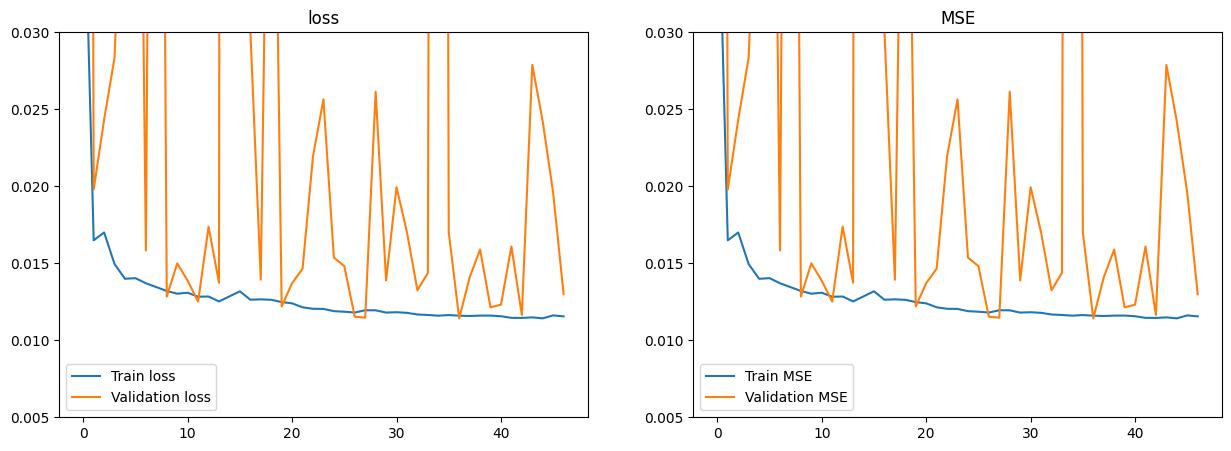

In [45]:
plot_history(history)

### Saving model

In [46]:
joblib.dump(model, "/kaggle/working/model.joblib")

['/kaggle/working/model.joblib']

## Testing reconstruction on image from train set

In [47]:
image_color_path = '/kaggle/input/datasets/aayush9753/image-colorization-dataset/data/train_color/image0001.jpg'

In [48]:
img = np.array(Image.open(image_color_path).resize((256,256)))
img.shape
L, ab = rgb_to_lab(np.expand_dims(img, axis=0))

In [49]:
ab_pred = model.predict(L)

2026-05-18 14:28:13.248781: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 14:28:13.512231: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 14:28:13.911264: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 14:28:14.176688: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 14:28:15.250636: E external/local_xla/xla/stream_

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


In [50]:
ab_pred.shape

(1, 256, 256, 2)

In [51]:
img_lab_reconstructed = tf.concat([L * 100.0, ab_pred * 128.0], axis=-1)

In [52]:
img_rgb_reconstructed = tfio.experimental.color.lab_to_rgb(img_lab_reconstructed)
img_rgb_reconstructed.shape

TensorShape([1, 256, 256, 3])

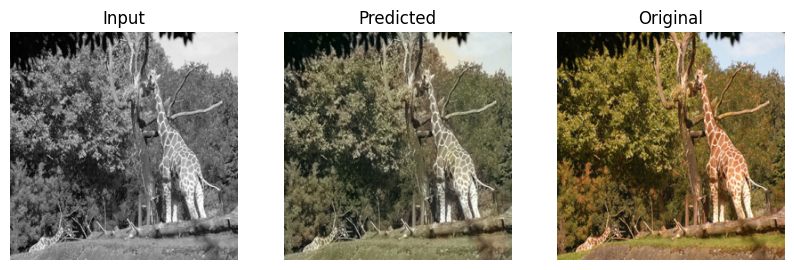

In [53]:
fig, ax = plt.subplots(1, 3, figsize=(10, 10))

ax[0].imshow(np.squeeze(L, axis=0), cmap='grey')
ax[0].axis('off')
ax[0].set_title('Input')

ax[1].imshow(np.squeeze(img_rgb_reconstructed,axis=0))
ax[1].axis('off')
ax[1].set_title('Predicted')

ax[2].imshow(img)
ax[2].axis('off')
ax[2].set_title('Original');